In [ ]:
# !pip install PyCaret

# Start

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

In [ ]:
df = pd.read_csv('/content/Dataset - Snake Gourd.csv')

In [ ]:
df.head()

,date,retail_price,inflation_ncip_food,inflation_ncip_non_food,inflation_ncip_all_items,national_production
0,2014-01-01,82.56,14198.75000,18921.70000,33139.11000,3935.3
1,2014-02-01,80.36,14127.75625,18978.46510,33105.97089,3935.3
2,2014-03-01,79.39,14170.13952,18997.44357,33172.18283,3935.3
3,2014-04-01,83.96,14411.03189,19054.43590,33470.73248,2243.2
4,2014-05-01,105.95,14684.84150,19054.43590,33738.49834,2243.2


In [ ]:
df.rename(columns={
    'Retail Price': 'retail_price',
    'inflation_ncip_food': 'ncpi_food',
    'inflation_ncip_non_food': 'ncpi_non_food',
    'inflation_ncip_all_items': 'ncpi_all_items',
}, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 132 non-null    object 
 1   retail_price         129 non-null    float64
 2   ncpi_food            132 non-null    float64
 3   ncpi_non_food        132 non-null    float64
 4   ncpi_all_items       132 non-null    float64
 5   national_production  123 non-null    float64
dtypes: float64(5), object(1)
memory usage: 6.3+ KB


In [ ]:
df.describe()

,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,national_production
count,129.000000,132.000000,132.000000,132.000000,123.000000
mean,188.124884,25138.207213,30908.198703,55963.146748,2767.997561
std,91.384610,12167.347008,15218.021473,27317.687025,670.664082
min,79.390000,14127.756250,18844.597440,33105.970890,2065.300000
25%,123.620000,16772.795965,20683.920375,37177.949780,2280.200000
50%,150.540000,18684.351785,23739.449425,41634.862270,2484.300000
75%,249.640000,32173.716705,39309.011675,71463.339945,2993.700000
max,447.600000,48340.283560,61048.737030,108982.262800,4915.200000


In [ ]:
df.isnull().sum()

,0
date,0
retail_price,3
ncpi_food,0
ncpi_non_food,0
ncpi_all_items,0
national_production,9


In [ ]:
df.drop(columns=["national_production"], inplace=True)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
date,0
retail_price,0
ncpi_food,0
ncpi_non_food,0
ncpi_all_items,0


In [ ]:
df.reset_index(inplace=True)

In [ ]:
df["Date"] = df["date"].astype("datetime64[ns]")
df["date"] = df["Date"].map(lambda x: (x).toordinal())
print(df[["Date", "date"]].head())
df.head()

        Date    date
0 2014-01-01  735234
1 2014-02-01  735265
2 2014-03-01  735293
3 2014-04-01  735324
4 2014-05-01  735354


,index,date,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,Date
0,0,735234,82.56,14198.75000,18921.70000,33139.11000,2014-01-01
1,1,735265,80.36,14127.75625,18978.46510,33105.97089,2014-02-01
2,2,735293,79.39,14170.13952,18997.44357,33172.18283,2014-03-01
3,3,735324,83.96,14411.03189,19054.43590,33470.73248,2014-04-01
4,4,735354,105.95,14684.84150,19054.43590,33738.49834,2014-05-01


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   index           129 non-null    int64         
 1   date            129 non-null    int64         
 2   retail_price    129 non-null    float64       
 3   ncpi_food       129 non-null    float64       
 4   ncpi_non_food   129 non-null    float64       
 5   ncpi_all_items  129 non-null    float64       
 6   Date            129 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 7.2 KB


In [ ]:
df.drop(columns=["Date"], inplace=True)

# Visualization

The trends of the price over time using a simple line plot

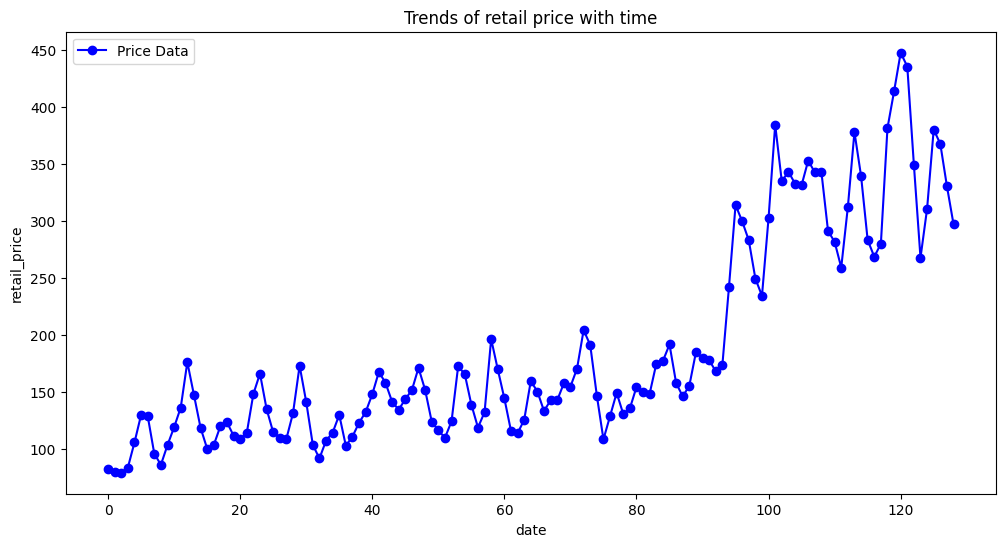

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['index'], df['retail_price'], marker='o', linestyle='-', color='b', label='Price Data')

# Labels and title
plt.xlabel('date')
plt.ylabel('retail_price')
plt.title('Trends of retail price with time')
plt.legend()

# Show grid and plot
plt.show()

The Seasonal decompose returns 4 plots.
1. General view of the data in thoughout time
2. Trends of the overall growth or loss of the values
3. Seasonality the common instances or actions in a given time period
4. Residual the values that do not fit the above 2 situations and are either random unexplained variations or just random noise

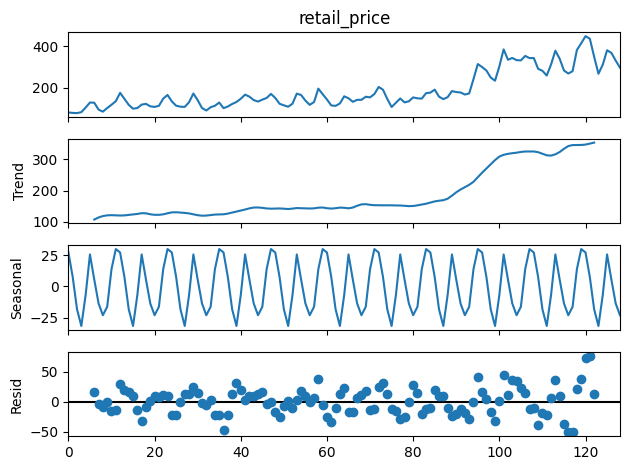

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df["retail_price"], model="additive", period=12)
decomposition.plot()
plt.show()

Trend --> The trend shows a small average growth until about 60% of the timeline, but afterwards a larger variance is visible.
Seasonal --> The series shows a strong seasonal behaviour
Residual --> There is a uniform residual spread throughout the time frame

The rolling mean/moving average will be used to smoothen values and identify the influence on the traget value due to external/other factors

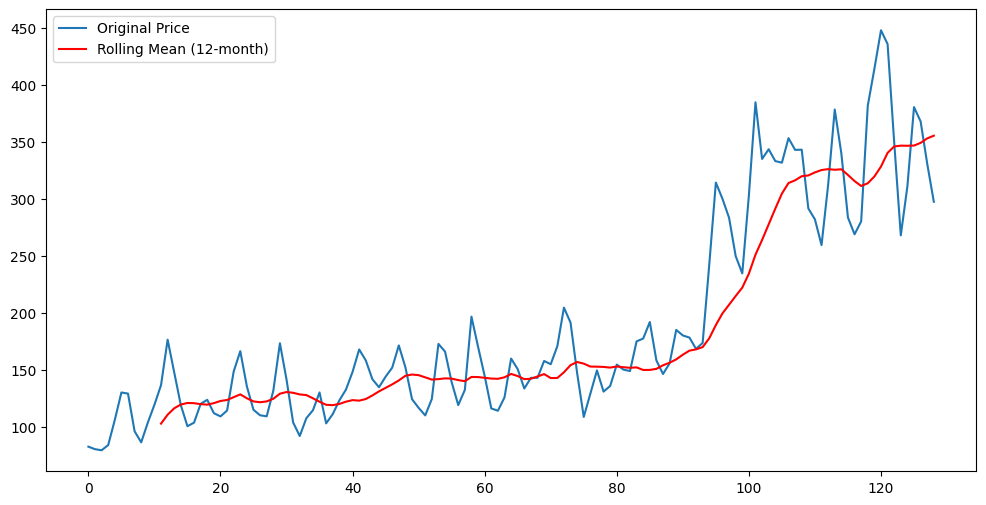

In [ ]:
df["rolling_mean"] = df["retail_price"].rolling(window=12).mean()

plt.figure(figsize=(12, 6))
plt.plot(df['retail_price'], label="Original Price")
plt.plot(df["rolling_mean"], color="red", label="Rolling Mean (12-month)")
plt.legend()
plt.show()

The moving average shows a uniform and steady progression until about the x-axis 90 value, but there after the is a an extreme external factor that pushes the mean to a larger value, this is assumed to be the financial crisis of Sri Lanka and the high demand of produces during that time period. Additionally although the mean average shows a uniform straight line for most of the time there are distinguishable spikes and drops of values relative to the average, which can be due the a vital external factor which I assume to be the inflation.

Inflation NCIP Food

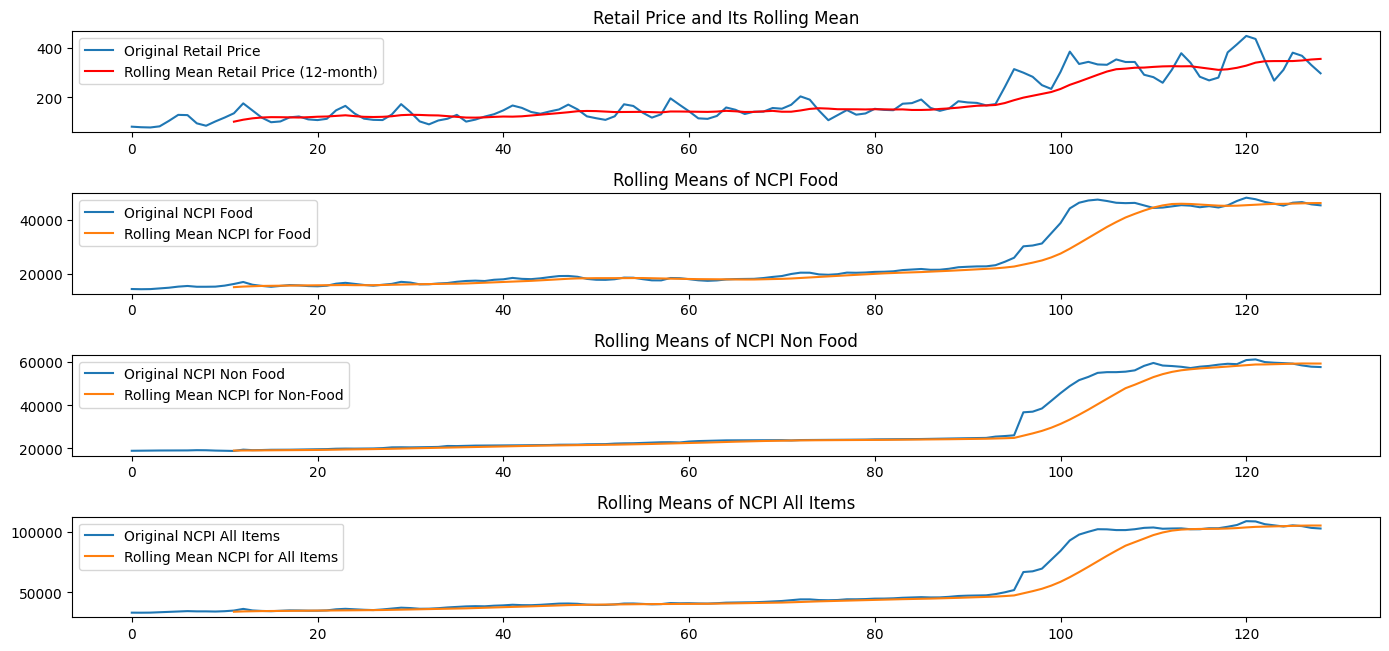

In [ ]:
df["rolling_mean_retail_price"] = df["retail_price"].rolling(window=12).mean()
df["rolling_mean_ncpi_food"] = df["ncpi_food"].rolling(window=12).mean()
df["rolling_mean_ncpi_non_food"] = df["ncpi_non_food"].rolling(window=12).mean()
df["rolling_mean_ncpi_all_items"] = df["ncpi_all_items"].rolling(window=12).mean()

plt.figure(figsize=(14, 8))

plt.subplot(5, 1, 1)
plt.plot(df['retail_price'], label="Original Retail Price")
plt.plot(df["rolling_mean_retail_price"], color="red", label="Rolling Mean Retail Price (12-month)")
plt.legend()
plt.title("Retail Price and Its Rolling Mean")

plt.subplot(5, 1, 2)
plt.plot(df['ncpi_food'], label="Original NCPI Food")
plt.plot(df["rolling_mean_ncpi_food"], label="Rolling Mean NCPI for Food")
plt.legend()
plt.title("Rolling Means of NCPI Food")

plt.subplot(5, 1, 3)
plt.plot(df['ncpi_non_food'], label="Original NCPI Non Food")
plt.plot(df["rolling_mean_ncpi_non_food"], label="Rolling Mean NCPI for Non-Food")
plt.legend()
plt.title("Rolling Means of NCPI Non Food")

plt.subplot(5, 1, 4)
plt.plot(df['ncpi_all_items'], label="Original NCPI All Items")
plt.plot(df["rolling_mean_ncpi_all_items"], label="Rolling Mean NCPI for All Items")
plt.legend()
plt.title("Rolling Means of NCPI All Items")

plt.tight_layout()
plt.show()

The mean for the NCIP seems to be very similar to the original value throughtout the plot, and the sudden change in the 90s range can be attributed to the financial crisis of Sri Lanka where the value of the Sri Lankan Ruppee greately deprciated. The NCPI means seems to have a highly similar mean trend to the retail price. The correlation of these 4 columns is expected to be over 0.7, which needs to be verified. The national production seems to have a several growth slopes especiall from aout 78 to 85 and a large drop from 85 to 98. This can be attributed to the poor quality of data taken for the national production.

Calculating the mean absolute error for the retail price and the NCPI

In [ ]:
from sklearn.metrics import r2_score
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Compute MAPE and R² for each rolling mean series
columns = ['ncpi_food', 'ncpi_non_food', 'ncpi_all_items', 'retail_price']
metrics = {}

for col in columns:
    y_true = df[col].dropna()
    y_pred = df[f'rolling_mean_{col}'].dropna()

    # Ensure both series have the same index after dropping NaNs
    y_true, y_pred = y_true.align(y_pred, join='inner')

    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    metrics[col] = {'MAPE': mape, 'R²': r2}

# Print results
for col, values in metrics.items():
    print(f"{col} -> MAPE: {values['MAPE']:.2f}%, R²: {values['R²']:.4f}")


ncpi_food -> MAPE: 5.46%, R²: 0.9158
ncpi_non_food -> MAPE: 4.61%, R²: 0.9208
ncpi_all_items -> MAPE: 4.66%, R²: 0.9207
retail_price -> MAPE: 13.85%, R²: 0.8119


As calculated above the NCPI mean absolute percentage error is less than 6% and the R² is over 0.9 shows a very accurate smoothing of the NCPI. The retail price has a moderate smoothening, this could be due to the seasonality and the high density of residuals which impact the calculations in the retail price. More verification through other smoothening evaluations are required for the confrimation of this. The national production has a highly inaccurate plot eventhough the MAPE is low which can be attributed to the low quality of data points. Hence it is reccomended to remove this column as it may affect the predictions that are to be made.

Verifing the correlation of the NCPI values with the retail price.

In [ ]:
df[['retail_price', 'ncpi_food', 'ncpi_non_food', 'ncpi_all_items']].corr()

,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items
retail_price,1.000000,0.942471,0.919528,0.931713
ncpi_food,0.942471,1.000000,0.991904,0.997537
ncpi_non_food,0.919528,0.991904,1.000000,0.998366
ncpi_all_items,0.931713,0.997537,0.998366,1.000000


As shown above is is evident that the ncip inflation has a significant impact on the retail price as all NCPI indexes exceed reached roughly 0.9. The national production shows a low correlation with retail price.

In [ ]:
df.tail()

,index,date,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,rolling_mean,rolling_mean_retail_price,rolling_mean_ncpi_food,rolling_mean_ncpi_non_food,rolling_mean_ncpi_all_items
124,124,739007,310.90,45364.99249,59350.03761,104572.2285,346.357500,346.357500,46035.722366,58958.445632,104857.621525
125,125,739038,380.27,46453.75231,59112.63746,105513.3785,346.539167,346.539167,46111.891773,59080.317933,105066.019742
126,126,739068,367.68,46686.02107,58285.06053,104880.2982,348.877500,348.877500,46222.596817,59181.267298,105281.751950
127,127,739099,330.64,45845.67269,57702.20993,103411.9741,352.812500,352.812500,46312.410188,59181.328251,105375.123817
128,128,739130,297.26,45478.90731,57529.10330,102894.9142,355.189167,355.189167,46338.083842,59138.112912,105357.213017


<Figure size 1000x600 with 0 Axes>

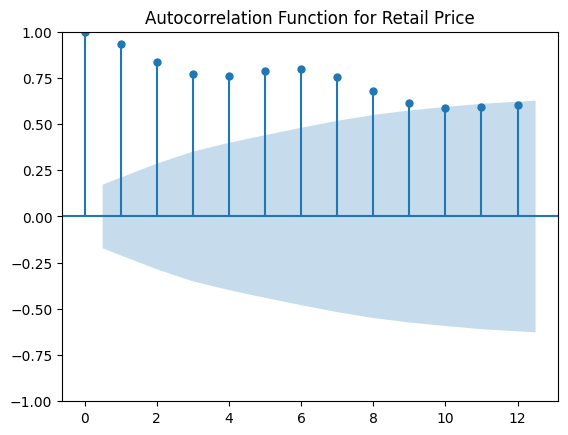

In [ ]:
plt.figure(figsize=(10, 6))
plot_acf(df['retail_price'], lags=12)
plt.title('Autocorrelation Function for Retail Price')
plt.show()

# Plot ACF for National Production
# plt.figure(figsize=(10, 6))
# plot_acf(df['National Production'], lags=40)  # Adjust lags as needed
# plt.title('Autocorrelation Function for National Production')
# plt.show()

<Figure size 1000x600 with 0 Axes>

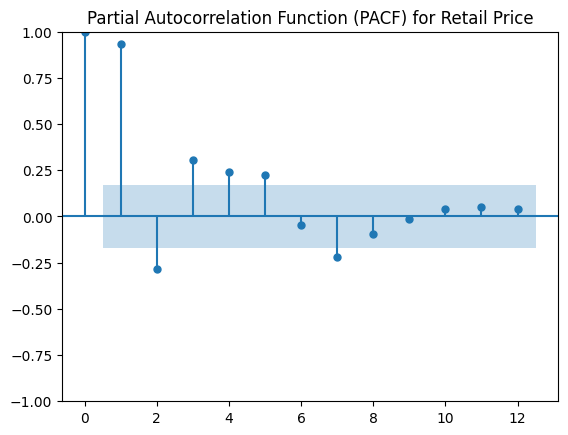

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plot_pacf(df['retail_price'], lags=12, method='ywm')  # 'ywm' is a stable method for PACF
plt.title('Partial Autocorrelation Function (PACF) for Retail Price')
plt.show()


Checking for outliers using IQR method

In [ ]:
import plotly.express as px

plt = px.box(df['retail_price'])
plt.show()

Although there are outliers present it cannot be reomved as all the values are extremely important. Hence the Z-score will be used to identify if the outliers instead of the IQR

Checking outliers using the Z-score

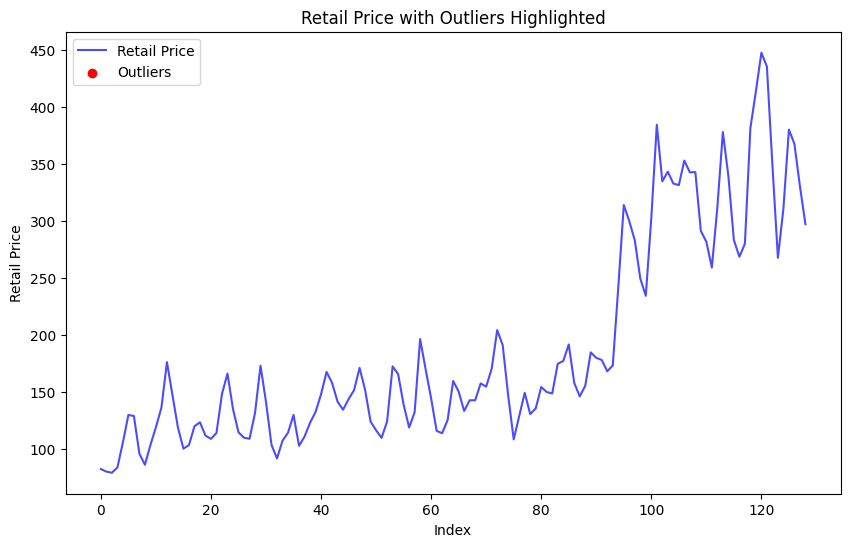

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import zscore

# Assuming df has a column 'retail_price'
df["z_score"] = zscore(df['retail_price'])

# Detect outliers (Z-score > 3 or < -3)
outliers = df[df["z_score"].abs() > 3]

# Plotting the retail_price and highlighting the outliers
plt.figure(figsize=(10, 6))
plt.plot(df['retail_price'], label='Retail Price', color='blue', alpha=0.7)
plt.scatter(outliers.index, outliers['retail_price'], color='red', label='Outliers', zorder=5)
plt.title('Retail Price with Outliers Highlighted')
plt.xlabel('Index')
plt.ylabel('Retail Price')
plt.legend()
plt.show()

As observed above there are only 2 outliers, hence I have decided to keep the outliers and progress.

In [ ]:
df.head()

,index,date,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,rolling_mean,rolling_mean_retail_price,rolling_mean_ncpi_food,rolling_mean_ncpi_non_food,rolling_mean_ncpi_all_items,z_score
0,0,735234,82.56,14198.75000,18921.70000,33139.11000,NaN,NaN,NaN,NaN,NaN,-1.159675
1,1,735265,80.36,14127.75625,18978.46510,33105.97089,NaN,NaN,NaN,NaN,NaN,-1.183843
2,2,735293,79.39,14170.13952,18997.44357,33172.18283,NaN,NaN,NaN,NaN,NaN,-1.194499
3,3,735324,83.96,14411.03189,19054.43590,33470.73248,NaN,NaN,NaN,NaN,NaN,-1.144295
4,4,735354,105.95,14684.84150,19054.43590,33738.49834,NaN,NaN,NaN,NaN,NaN,-0.902726


In [ ]:
df.drop(columns=["rolling_mean", "rolling_mean_retail_price", "rolling_mean_ncpi_food", "rolling_mean_ncpi_non_food", "rolling_mean_ncpi_all_items", "z_score"], axis=1, inplace=True)

In [ ]:
df.columns

Index(['index', 'date', 'retail_price', 'ncpi_food', 'ncpi_non_food',
       'ncpi_all_items'],
      dtype='object')

# DF Man

In [ ]:
df.to_csv("prepared_snake_gourd.csv", index=False)

In [ ]:
df.head()

,index,date,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items
0,0,735234,82.56,14198.75000,18921.70000,33139.11000
1,1,735265,80.36,14127.75625,18978.46510,33105.97089
2,2,735293,79.39,14170.13952,18997.44357,33172.18283
3,3,735324,83.96,14411.03189,19054.43590,33470.73248
4,4,735354,105.95,14684.84150,19054.43590,33738.49834


In [ ]:
df.head()

,index,date,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items
0,0,735234,82.56,14198.75000,18921.70000,33139.11000
1,1,735265,80.36,14127.75625,18978.46510,33105.97089
2,2,735293,79.39,14170.13952,18997.44357,33172.18283
3,3,735324,83.96,14411.03189,19054.43590,33470.73248
4,4,735354,105.95,14684.84150,19054.43590,33738.49834


In [ ]:
prep_df = pd.read_csv("/content/prepared_snake_gourd.csv")

In [ ]:
filtered_df = prep_df.query("date <= 738855")

In [ ]:
filtered_df.tail()

,index,date,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items
115,115,738733,283.42,44767.91225,57701.47850,102291.5117
116,116,738764,268.74,45170.82346,58047.68737,103109.8438
117,117,738794,280.04,44673.94440,58628.16424,103109.8438
118,118,738825,381.52,45478.07540,59038.56139,104347.1619
119,119,738855,413.74,47115.28612,58861.44571,105808.0221


In [ ]:
filtered_df.to_csv("filtered_snake_gourd.csv", index=False)

# Pipeline

In [ ]:
prep_df = pd.read_csv("/content/prepared_snake_gourd.csv")

In [ ]:
prep_df.head()

,Unnamed: 0,index,date,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items
0,0,0,735234,82.56,14198.75000,18921.70000,33139.11000
1,1,1,735265,80.36,14127.75625,18978.46510,33105.97089
2,2,2,735293,79.39,14170.13952,18997.44357,33172.18283
3,3,3,735324,83.96,14411.03189,19054.43590,33470.73248
4,4,4,735354,105.95,14684.84150,19054.43590,33738.49834


In [ ]:
from pycaret.regression import *

In [ ]:
clf = setup(data=prep_df, target='retail_price', session_id=777)

,Description,Value
0,Session id,777
1,Target,retail_price
2,Target type,Regression
3,Original data shape,"(129, 7)"
4,Transformed data shape,"(129, 7)"
5,Transformed train set shape,"(90, 7)"
6,Transformed test set shape,"(39, 7)"
7,Numeric features,6
8,Preprocess,True
9,Imputation type,simple


In [ ]:
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,15.8712,505.6694,21.7615,0.9346,0.1027,0.0838,0.1180
rf,Random Forest Regressor,17.7057,601.4064,23.8117,0.9197,0.1176,0.0977,0.1630
knn,K Neighbors Regressor,19.2708,624.6236,24.5129,0.9155,0.1421,0.1162,0.0280
gbr,Gradient Boosting Regressor,17.7688,661.3627,24.8999,0.9139,0.1123,0.0926,0.0750
huber,Huber Regressor,20.0948,714.2497,25.8773,0.8998,0.1361,0.1131,0.0330
lasso,Lasso Regression,20.2172,706.9372,25.6608,0.8951,0.1365,0.1169,0.0400
en,Elastic Net,20.2172,706.9374,25.6608,0.8951,0.1365,0.1169,0.0480
llar,Lasso Least Angle Regression,20.1663,704.7463,25.6365,0.8945,0.1342,0.1155,0.0230
ridge,Ridge Regression,20.1921,706.4331,25.6690,0.8943,0.1343,0.1156,0.0350
br,Bayesian Ridge,20.1693,709.0523,25.6864,0.8942,0.1372,0.1173,0.0250


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
from pycaret.time_series import *

In [ ]:
clf = setup(data=prep_df, target='retail_price', session_id=778)

,Description,Value
0,session_id,778
1,Target,retail_price
2,Approach,Univariate
3,Exogenous Variables,Present
4,Original data shape,"(129, 7)"
5,Transformed data shape,"(129, 7)"
6,Transformed train set shape,"(128, 7)"
7,Transformed test set shape,"(1, 7)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


In [ ]:
ts_best_model = compare_models()

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,TT (Sec)
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,0.0927,0.0689,3.0851,3.0851,0.0093,0.0091,0.1233
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,0.1755,0.1304,5.8276,5.8276,0.0171,0.0168,0.1300
omp_cds_dt,Orthogonal Matching Pursuit w/ Cond. Deseasonalize & Detrending,0.3254,0.2418,10.8061,10.8061,0.0319,0.0309,0.1167
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.3653,0.2705,12.0239,12.0239,0.0319,0.0329,0.3067
br_cds_dt,Bayesian Ridge w/ Cond. Deseasonalize & Detrending,0.3877,0.2870,12.7602,12.7602,0.0336,0.0352,0.1167
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.3922,0.2905,12.9201,12.9201,0.0345,0.0357,0.1167
llar_cds_dt,Lasso Least Angular Regressor w/ Cond. Deseasonalize & Detrending,0.3932,0.2912,12.9520,12.9520,0.0346,0.0358,0.1133
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,0.3981,0.2948,13.1137,13.1137,0.0350,0.0364,0.1200
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,0.4001,0.2963,13.1794,13.1794,0.0352,0.0366,0.1133
ada_cds_dt,AdaBoost w/ Cond. Deseasonalize & Detrending,0.4319,0.3208,14.3309,14.3309,0.0418,0.0405,0.1900


Processing:   0%|          | 0/85 [00:00<?, ?it/s]

# Linear Regession

In [ ]:
prep_df = pd.read_csv("/content/prepared_snake_gourd.csv")

In [ ]:
df.head()

,index,date,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items
0,0,735234,82.56,14198.75000,18921.70000,33139.11000
1,1,735265,80.36,14127.75625,18978.46510,33105.97089
2,2,735293,79.39,14170.13952,18997.44357,33172.18283
3,3,735324,83.96,14411.03189,19054.43590,33470.73248
4,4,735354,105.95,14684.84150,19054.43590,33738.49834


In [ ]:
X = prep_df.drop(columns=["retail_price", "index"])
y = prep_df["retail_price"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size = 0.8)

In [ ]:
print('X_train shape', X_train.shape)
print('X_test shape', X_test.shape)

X_train shape (25, 5)
X_test shape (104, 5)


In [ ]:
from sklearn.linear_model import LinearRegression

slr_model = LinearRegression()
slr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
slope = slr_model.coef_
y_intercept = slr_model.intercept_
print('Slope', slope)
print('Intercept', y_intercept)

Slope [-55.45426141   1.81823939   0.13867112   0.11691132  -0.12373743]
Intercept -1336818.1825202836


In [ ]:
y_pred_train = slr_model.predict(X_train)

In [ ]:
y_pred_test = slr_model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
r2_train = r2_score(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)

print('R2 score on train set', r2_train)
print('MSE on train set', mse_train)

R2 score on train set 0.9618282183742686
MSE on train set 295.47422065966055


In [ ]:
Comparison_df = pd.DataFrame({'Actual' : y_test,  'Predicted' : y_pred_test})
Comparison_df.to_csv(r'/content/Comparison_df.csv', index=True)
Comparison_df

,Actual,Predicted
55,139.16,126.606394
40,148.15,134.604424
19,111.92,121.806902
31,103.81,121.706899
114,339.62,302.157066
...,...,...
75,108.61,134.312697
32,91.89,127.646656
121,435.48,301.879980
59,170.06,135.043874


# Lasso Regression

In [ ]:
prep_df = pd.read_csv("/content/prepared_snake_gourd.csv")

In [ ]:
df.head()

,index,date,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items
0,0,735234,82.56,14198.75000,18921.70000,33139.11000
1,1,735265,80.36,14127.75625,18978.46510,33105.97089
2,2,735293,79.39,14170.13952,18997.44357,33172.18283
3,3,735324,83.96,14411.03189,19054.43590,33470.73248
4,4,735354,105.95,14684.84150,19054.43590,33738.49834


In [ ]:
X = prep_df.drop(columns=["retail_price", "index"])
y = prep_df["retail_price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [ ]:
y_pred = lasso.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

Mean Squared Error: 755.966610936818
R² Score: 0.9079999339302548


In [ ]:
y_pred_test = slr_model.predict(X_test)

In [ ]:
y_pred_train = slr_model.predict(X_train)

In [ ]:
Comparison_df = pd.DataFrame({'Actual' : y_test,  'Predicted' : y_pred_test})
Comparison_df.to_csv(r'/content/Comparison_df.csv', index=True)
Comparison_df

,Actual,Predicted
55,139.16,126.606394
40,148.15,134.604424
19,111.92,121.806902
31,103.81,121.706899
114,339.62,302.157066
56,119.01,121.284607
69,157.70,128.806491
105,331.53,335.192758
81,150.13,153.935362
26,110.05,123.057522


# Auto ARIMA

In [ ]:
prep_df = pd.read_csv("/content/prepared_snake_gourd.csv", parse_dates=['date'], index_col='date')

In [ ]:
prep_df.head()

,Unnamed: 0,index,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items
date,,,,,,
735234,0,0,82.56,14198.75000,18921.70000,33139.11000
735265,1,1,80.36,14127.75625,18978.46510,33105.97089
735293,2,2,79.39,14170.13952,18997.44357,33172.18283
735324,3,3,83.96,14411.03189,19054.43590,33470.73248
735354,4,4,105.95,14684.84150,19054.43590,33738.49834


In [ ]:
from pmdarima import auto_arima

model = auto_arima(prep_df['retail_price'], seasonal=True, m=12, stepwise=True, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1178.968, Time=1.34 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1241.627, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1210.891, Time=0.26 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1213.334, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1240.015, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=1187.207, Time=0.53 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=1185.612, Time=0.65 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=1180.962, Time=2.78 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=1181.061, Time=3.84 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=1187.756, Time=0.40 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=1186.837, Time=1.39 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=1185.016, Time=2.08 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=inf, Time=2.83 sec
 ARIMA(1,1,2)(1,0,1)[12] intercept   : AIC=1184.495, Time=1.04 sec
 ARIMA(2,1,1)(1,0,1)[12]

In [ ]:
forecast, conf_int = model.predict(n_periods=12, return_conf_int=True)

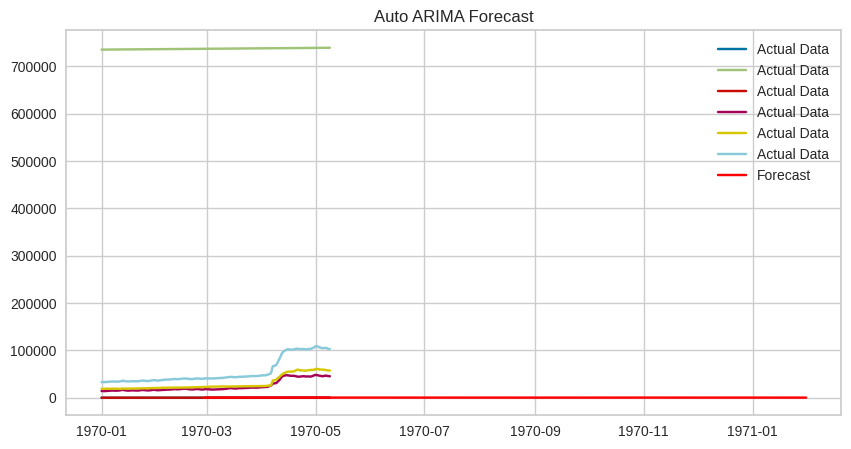

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df, label="Actual Data")
plt.plot(pd.date_range(start=df.index[-1], periods=13, freq='M')[1:], forecast, label="Forecast", color='red')
plt.fill_between(pd.date_range(start=df.index[-1], periods=13, freq='M')[1:],
                 conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)
plt.legend()
plt.title("Auto ARIMA Forecast")
plt.show()

In [ ]:
print(forecast, conf_int)

129    304.419388
130    350.402664
131    375.396716
132    379.743529
133    362.337383
134    333.664070
135    311.614079
136    339.935334
137    377.697464
138    361.707733
139    345.692124
140    335.562861
dtype: float64 [[260.68004995 348.15872581]
 [283.86897378 416.93635412]
 [299.94550104 450.84793061]
 [301.15395264 458.33310562]
 [281.63865782 443.03610806]
 [250.12007363 417.20806671]
 [224.21694972 399.01120821]
 [248.39977811 431.47089085]
 [282.38249081 473.01243658]
 [263.06164695 460.35381986]
 [243.96591582 447.41833155]
 [230.82747773 440.2982442 ]]


# Extra Tree Regressor

In [ ]:
prep_df = pd.read_csv("/content/prepared_snake_gourd.csv")

In [ ]:
filtered_df = pd.read_csv("/content/filtered_snake_gourd.csv")

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split

# Generate sample dataset
X = filtered_df.drop(columns=["retail_price", "index"])
y = filtered_df["retail_price"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train Extra Trees Regressor
# n_estimators are the number of decision trees
# criterion is the method on how the branching of the node are determined
# possion give a r2 value of 0.9148 ans mse of 797.4340
etr = ExtraTreesRegressor(n_estimators=100, criterion="absolute_error", random_state=42)
etr.fit(X_train, y_train)

# Predict on test data
y_pred = etr.predict(X_test)

# Evaluate the model
# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print(f"Mean Squared Error: {mse:.4f}")
# print(f"R² Score: {r2:.4f}")

# Plot results
# plt.scatter(X_test, y_test, color="blue", label="Actual")
# plt.scatter(X_test, y_pred, color="red", label="Predicted")
# plt.xlabel("X")
# plt.ylabel("y")
# plt.legend()
# plt.title("Extra Trees Regressor")
# plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Percentage Error: {mape:.4f}")

Mean Squared Error: 228.6572
R² Score: 0.9573
Mean Absolute Error: 11.5427
Root Mean Squared Error: 15.1214
Mean Absolute Percentage Error: 0.0674


In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Define parameter grid
param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ['sqrt', 'log2', None],
    "criterion": ["squared_error", "absolute_error", "poisson"],
    "bootstrap": [True, False]
}

# Initialize Extra Trees Regressor
etr = ExtraTreesRegressor(random_state=42)

# Perform Randomized Search
random_search = RandomizedSearchCV(
    etr, param_distributions=param_dist, n_iter=50,
    cv=5, scoring="r2", n_jobs=-1, random_state=42
)

random_search.fit(X_train, y_train)

# Get the best model and parameters
best_model = random_search.best_estimator_
best_params = random_search.best_params_

# Evaluate the best model
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Best Parameters:", best_params)
print(f"Fine-Tuned MSE: {mse:.4f}")
print(f"Fine-Tuned R² Score: {r2:.4f}")


Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'criterion': 'squared_error', 'bootstrap': False}
Fine-Tuned MSE: 227.4155
Fine-Tuned R² Score: 0.9575


In [ ]:
filtered_df = pd.read_csv("/content/filtered_snake_gourd.csv")

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split

# Generate sample dataset
X = filtered_df.drop(columns=["retail_price", "index"])
y = filtered_df["retail_price"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train Extra Trees Regressor
# n_estimators are the number of decision trees
# criterion is the method on how the branching of the node are determined
# possion give a r2 value of 0.9148 ans mse of 797.4340
tuned_etr = ExtraTreesRegressor(n_estimators=200, criterion="squared_error", max_features="log2", max_depth=20, random_state=42)
tuned_etr.fit(X_train, y_train)

# Predict on test data
y_pred = tuned_etr.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# Plot results
# plt.scatter(X_test, y_test, color="blue", label="Actual")
# plt.scatter(X_test, y_pred, color="red", label="Predicted")
# plt.xlabel("X")
# plt.ylabel("y")
# plt.legend()
# plt.title("Extra Trees Regressor")
# plt.show()

Mean Squared Error: 227.4155
R² Score: 0.9575


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Percentage Error: {mape:.4f}")

Mean Squared Error: 227.4155
R² Score: 0.9575
Mean Absolute Error: 11.1760
Root Mean Squared Error: 15.0803
Mean Absolute Percentage Error: 0.0657


In [ ]:
import joblib

joblib.dump(tuned_etr, 'etr_snake_gourd_model.pkl')

['etr_snake_gourd_model.pkl']

In [ ]:
prep_df.tail(9)

,index,date,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items
120,120,738886,447.60,48340.28356,60745.01197,108982.2628
121,121,738917,435.48,47760.20015,61048.73703,108764.2983
122,122,738946,349.33,46757.23595,59827.76229,106480.2480
123,123,738977,267.81,46102.63465,59528.62348,105521.9258
124,124,739007,310.90,45364.99249,59350.03761,104572.2285
125,125,739038,380.27,46453.75231,59112.63746,105513.3785
126,126,739068,367.68,46686.02107,58285.06053,104880.2982
127,127,739099,330.64,45845.67269,57702.20993,103411.9741
128,128,739130,297.26,45478.90731,57529.10330,102894.9142


In [ ]:
data = {
    "ncpi_food": [48340.28356, 47760.20015, 46757.23595, 46102.63465, 45364.99249, 46453.75231, 46686.02107, 45845.67269, 45478.90731],
    "ncpi_non_food": [60745.01197, 61048.73703, 59827.76229, 59528.62348, 59350.03761, 59112.63746, 58285.06053, 57702.20993, 57529.10330],
    "ncpi_all_items": [108982.2628, 108764.2983, 106480.2480, 105521.9258, 104572.2285, 105513.3785, 104880.2982, 103411.9741, 102894.9142],
    "date": [738886, 738917, 738946, 738977, 739007, 739038, 739068, 739099, 739130]
}

# Create DataFrame
testing_df = pd.DataFrame(data)

In [ ]:
# !pip install --upgrade scikit-learn

In [ ]:
# print(etr.feature_names_in_)

In [ ]:
# Get the column names used during training (assuming they are stored in X_train)
training_columns = X_train.columns

# Reorder columns in testing_df to match the training data
testing_df = testing_df[training_columns]

# Now you can make predictions:
y_new_pred = tuned_etr.predict(testing_df)

In [ ]:
y_new_pred

array([409.5925 , 409.5925 , 404.7669 , 396.25815, 382.5184 , 397.6572 ,
       393.103  , 363.7767 , 356.07515])

In [ ]:
prep_df["retail_price"].tail()

In [ ]:
testing_df